Heart Disease Prediction Model

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

Start by preprocessing

In [2]:
data = pd.read_csv('heart.csv')
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


Turn Sex into 0,1 

In [6]:
data['Sex'] = data['Sex'].replace({'M': 0, 'F': 1}).astype(int)
data.head()

C:\Users\2024\AppData\Local\Temp\ipykernel_11784\20942436.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Sex'] = data['Sex'].replace({'M': 0, 'F': 1}).astype(int)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,1,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,0,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,1,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,0,NAP,150,195,0,Normal,122,N,0.0,Up,0


Check for null values

In [7]:
data.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Map out Chest Pain Type: ATA: 0, NAP: 1, ASY: 2, TA: 3

In [8]:
x = data['ChestPainType'].unique()
print(x)
#Lets map this out as well ATA: 0, NAP: 1, ASY: 2, TA: 3

['ATA' 'NAP' 'ASY' 'TA']


In [9]:
data['ChestPainType'] = data['ChestPainType'].replace({'ATA': 0, 'NAP': 1, 'ASY': 2, 'TA': 3}).astype(int)
data.head()

C:\Users\2024\AppData\Local\Temp\ipykernel_11784\265843650.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['ChestPainType'] = data['ChestPainType'].replace({'ATA': 0, 'NAP': 1, 'ASY': 2, 'TA': 3}).astype(int)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,0,140,289,0,Normal,172,N,0.0,Up,0
1,49,1,1,160,180,0,Normal,156,N,1.0,Flat,1
2,37,0,0,130,283,0,ST,98,N,0.0,Up,0
3,48,1,2,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,0,1,150,195,0,Normal,122,N,0.0,Up,0


Normal: 0, ST: 1, LVH: 2

In [10]:
x = data['RestingECG'].unique()
print(x)
#Lets map this out as well

['Normal' 'ST' 'LVH']


In [11]:
data['RestingECG'] = data['ChestPainType'].replace({'Normal': 0, 'ST': 1, 'LVH': 2}).astype(int)
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,0,140,289,0,0,172,N,0.0,Up,0
1,49,1,1,160,180,0,1,156,N,1.0,Flat,1
2,37,0,0,130,283,0,0,98,N,0.0,Up,0
3,48,1,2,138,214,0,2,108,Y,1.5,Flat,1
4,54,0,1,150,195,0,1,122,N,0.0,Up,0


In [12]:
data['ExerciseAngina'] = data['ExerciseAngina'].replace({'N': 0, 'Y': 1}).astype(int)
data.head()

C:\Users\2024\AppData\Local\Temp\ipykernel_11784\85929393.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['ExerciseAngina'] = data['ExerciseAngina'].replace({'N': 0, 'Y': 1}).astype(int)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,0,140,289,0,0,172,0,0.0,Up,0
1,49,1,1,160,180,0,1,156,0,1.0,Flat,1
2,37,0,0,130,283,0,0,98,0,0.0,Up,0
3,48,1,2,138,214,0,2,108,1,1.5,Flat,1
4,54,0,1,150,195,0,1,122,0,0.0,Up,0


In [13]:
x = data['ST_Slope'].unique()
print(x)

['Up' 'Flat' 'Down']


In [14]:
data['ST_Slope'] = data['ST_Slope'].replace({'Flat': 0, 'Up': 1, 'Down': 2}).astype(int)
data.head()

C:\Users\2024\AppData\Local\Temp\ipykernel_11784\3878147887.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['ST_Slope'] = data['ST_Slope'].replace({'Flat': 0, 'Up': 1, 'Down': 2}).astype(int)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,0,140,289,0,0,172,0,0.0,1,0
1,49,1,1,160,180,0,1,156,0,1.0,0,1
2,37,0,0,130,283,0,0,98,0,0.0,1,0
3,48,1,2,138,214,0,2,108,1,1.5,0,1
4,54,0,1,150,195,0,1,122,0,0.0,1,0


Correlation Matrix

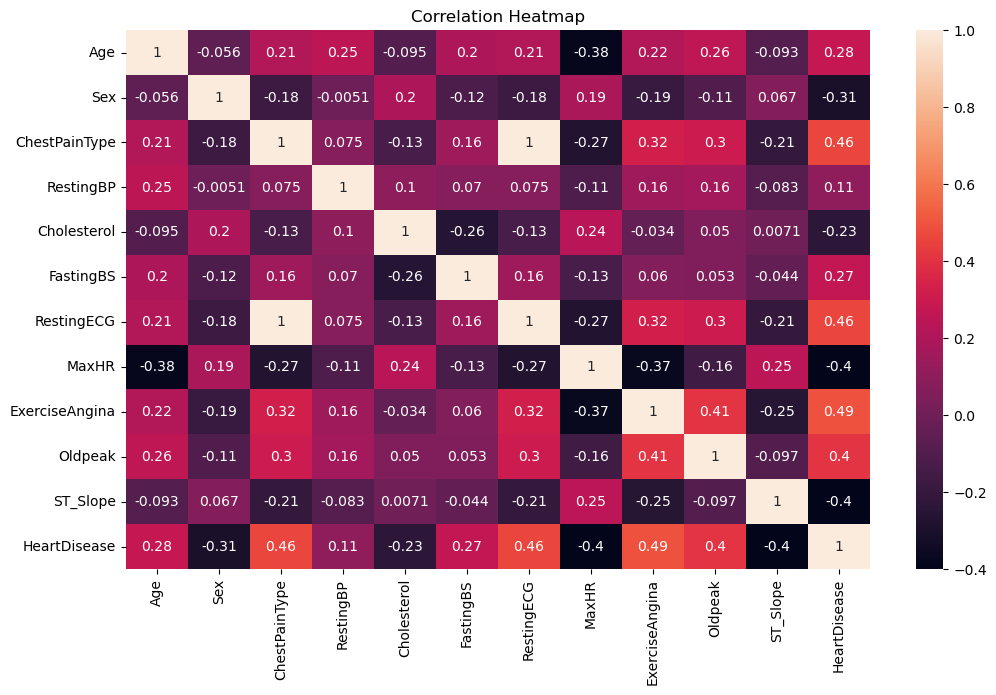

In [15]:
import seaborn as sns 

data_corr = data.corr()
plt.figure(figsize=(12,7))

sns.heatmap(data_corr, annot=True, cmap='rocket')
plt.title('Correlation Heatmap')
plt.show()

In [19]:
relevant_features = []
relevant_values = []

for label, value in data_corr['HeartDisease'].items():
    value = abs(value)
    if label != 'HeartDisease' and value > 0.1:
        relevant_features.append(label)
        relevant_values.append(value)

print(relevant_features)
print(relevant_values)

['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']
[0.2820385058189964, 0.3054449159631404, 0.45901696614239657, 0.10758898037140385, 0.2327406389270114, 0.26729118611029784, 0.45901696614239657, 0.4004207694631906, 0.4942819918242684, 0.40395072206288607, 0.39780171827774835]


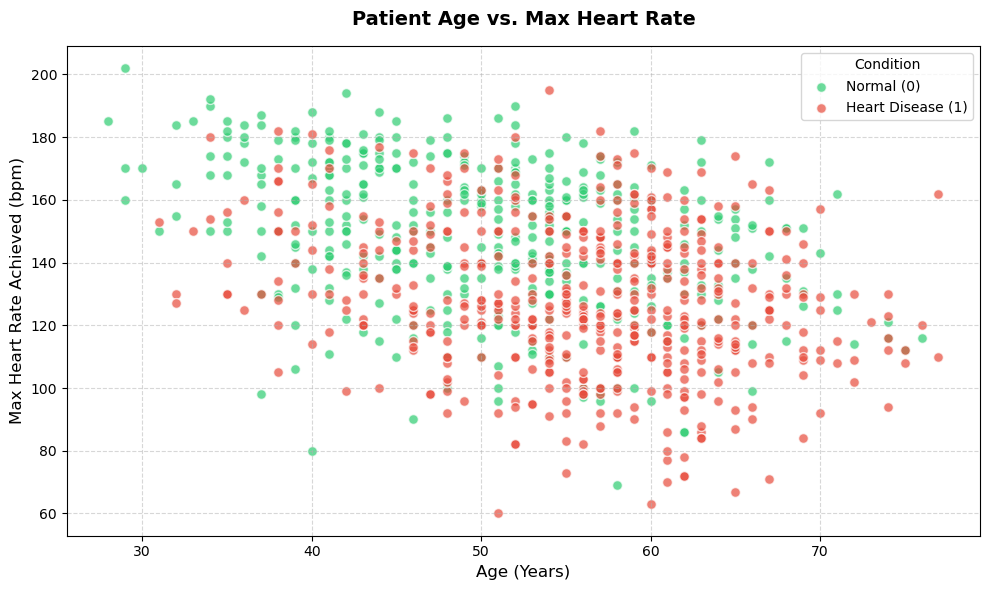

In [ ]:
import matplotlib.pyplot as plt

no_disease = data[data['HeartDisease'] == 0]
has_disease = data[data['HeartDisease'] == 1]

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    no_disease['Age'], 
    no_disease['MaxHR'], 
    color='#2ecc71', 
    label='Normal (0)', 
    alpha=0.7, 
    edgecolors='w',
    s=50
)

ax.scatter(
    has_disease['Age'], 
    has_disease['MaxHR'], 
    color='#e74c3c', 
    label='Heart Disease (1)', 
    alpha=0.7, 
    edgecolors='w',
    s=50
)

ax.set_title('Patient Age vs. Max Heart Rate', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Age (Years)', fontsize=12)
ax.set_ylabel('Max Heart Rate Achieved (bpm)', fontsize=12)

ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title='Condition', loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

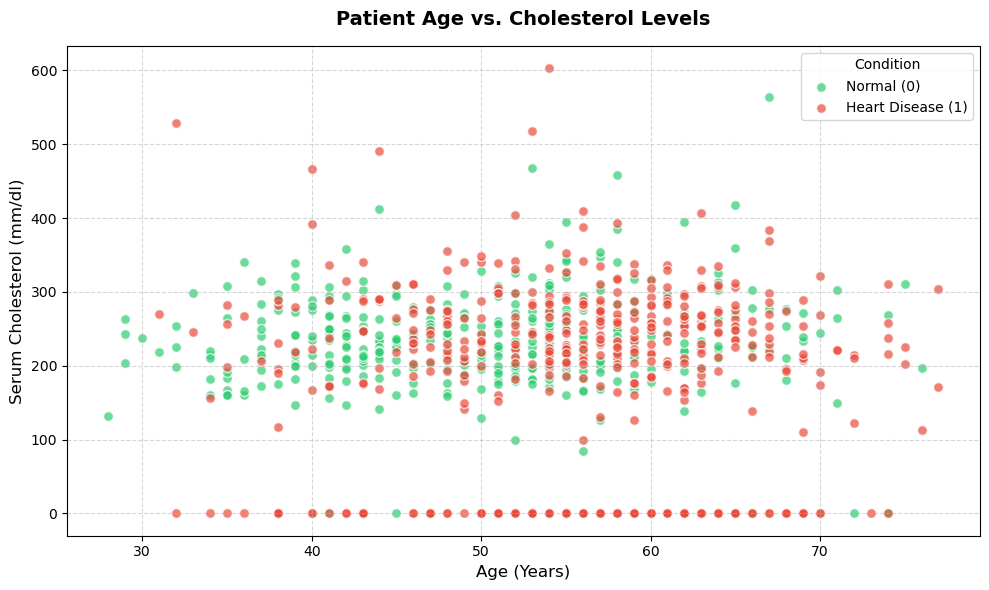

In [48]:
import matplotlib.pyplot as plt

no_disease = data[data['HeartDisease'] == 0]
has_disease = data[data['HeartDisease'] == 1]

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    no_disease['Age'], 
    no_disease['Cholesterol'], 
    color='#2ecc71', 
    label='Normal (0)', 
    alpha=0.7, 
    edgecolors='w',
    s=50
)

ax.scatter(
    has_disease['Age'], 
    has_disease['Cholesterol'], 
    color='#e74c3c', 
    label='Heart Disease (1)', 
    alpha=0.7, 
    edgecolors='w',
    s=50
)

ax.set_title('Patient Age vs. Cholesterol Levels', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Age (Years)', fontsize=12)
ax.set_ylabel('Serum Cholesterol (mm/dl)', fontsize=12)

ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title='Condition', loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

Train/Test Split (We won't need validation for this dataset) 80/20 split

In [23]:
from sklearn.model_selection import train_test_split

X = data[relevant_features]
y = data['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Length of X_train:', len(X_train))
print('Length of y_train:', len(y_train))

print('Length of X_test:', len(X_test))
print('Length of y_test:', len(y_test))

Length of X_train: 734
Length of y_train: 734
Length of X_test: 184
Length of y_test: 184


In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Lets try the model on Logistic Regression

In [26]:
from sklearn.linear_model import LogisticRegression

logistic_regression_model = LogisticRegression(C=1.0, solver='lbfgs', random_state=42)
logistic_regression_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [31]:
test_preds = logistic_regression_model.predict(X_test_scaled)

In [32]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, test_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, test_preds))
print("Detailed Metrics:\n", classification_report(y_test, test_preds))


Accuracy: 0.8206521739130435
Confusion Matrix:
 [[64 13]
 [20 87]]
Detailed Metrics:
               precision    recall  f1-score   support

           0       0.76      0.83      0.80        77
           1       0.87      0.81      0.84       107

    accuracy                           0.82       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.82      0.82      0.82       184



Lets test the model on Random Forest now

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],          
    'max_depth': [None, 10, 20, 30],       
    'min_samples_split': [2, 5, 10],         
    'min_samples_leaf': [1, 2, 4],           
    'criterion': ['gini', 'entropy']         
}
random_forest_model = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=random_forest_model, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1, 
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


c:\Users\2024\Python\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy', verbose=1)

In [ ]:
random_forest_best_model = grid_search.best_estimator_

accuracy = random_forest_best_model.score(X_test_scaled, y_test)
print(f"Test Set Accuracy: {accuracy:.4f}")

Test Set Accuracy: 0.8750


In [ ]:
from sklearn.metrics import classification_report, precision_score, f1_score

# 1. Generate predictions on the scaled test set
y_pred = random_forest_best_model.predict(X_test_scaled)

# 2. Calculate individual scores
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Test Set Accuracy: {accuracy:.4f}")
print(f"Precision:         {precision:.4f}")
print(f"F1-Score:          {f1:.4f}")

print("\n--- Full Classification Report ---")
print(classification_report(y_test, y_pred))

Test Set Accuracy: 0.8750
Precision:         0.8962
F1-Score:          0.8920

--- Full Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.86      0.85        77
           1       0.90      0.89      0.89       107

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184



Finally, lets try XGBoost

In [39]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

xgb_param_grid = {
    'n_estimators': [50, 100, 200],    
    'max_depth': [3, 5, 7],           
    'learning_rate': [0.01, 0.1, 0.2],  
    'subsample': [0.8, 1.0]               
}

xgboost_model = xgb.XGBClassifier(random_state=42)
xgb_grid_search = GridSearchCV(
    estimator=xgboost_model, 
    param_grid=xgb_param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1, 
    verbose=1
)
xgb_grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [50, 100, 200],
                         'subsample': [0.8, 1.0]},
             scoring='accuracy', verbose=1)

In [40]:
best_xgb_model = xgb_grid_search.best_estimator_

In [43]:
y_pred_xgb = best_xgb_model.predict(X_test_scaled)


xgb_accuracy = best_xgb_model.score(X_test_scaled, y_test)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

print(f"XGBoost Test Accuracy:  {xgb_accuracy:.4f}")
print(f"XGBoost Precision:      {xgb_precision:.4f}")
print(f"XGBoost F1-Score:       {xgb_f1:.4f}")

print("\n--- XGBoost Full Classification Report ---")
print(classification_report(y_test, y_pred_xgb))

XGBoost Test Accuracy:  0.8750
XGBoost Precision:      0.8962
XGBoost F1-Score:       0.8920

--- XGBoost Full Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.86      0.85        77
           1       0.90      0.89      0.89       107

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184



In [ ]:
from sklearn.metrics import roc_auc_score

rf_probs = random_forest_best_model.predict_proba(X_test_scaled)[:, 1]
xgb_probs = best_xgb_model.predict_proba(X_test_scaled)[:, 1]

print(f"Random Forest ROC-AUC: {roc_auc_score(y_test, rf_probs):.4f}")
print(f"XGBoost ROC-AUC:       {roc_auc_score(y_test, xgb_probs):.4f}")

Random Forest ROC-AUC: 0.9307
XGBoost ROC-AUC:       0.9359
